# Kapitel 6 – Stufe 2: Hypothesentestung
**Masterarbeit | Kapitel 6.2**  
Autor: Ayumi Nojima | April 2026

---
- **H1** – ANOVA: Unterschiede im Exposure-Index zwischen Hauptgruppen
- **H2** – Random Forest: Fähigkeitsmerkmale als Prädiktoren für E^sub_j
- **H3** – OLS-Regression: Zusammenhang E_j und ΔBFS_j

**Hypothesen (vgl. Kap. 4):**
- H1: E_j unterscheidet sich signifikant zwischen CH-ISCO-Hauptgruppen 1–3
- H2: Kognitive/sprachliche Fähigkeiten sind stärkste Prädiktoren für E^sub_j
- H3: Höherer E_j geht mit stärkerer Beschäftigungsveränderung einher (Displacement-Effekt)


## 0. Konfiguration und Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── Pfade ──────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if (_cwd / "..").resolve().joinpath("data").exists() else _cwd
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path.cwd()

PROCESSED = REPO_ROOT / "data" / "processed"
ANALYSIS  = PROCESSED / "analysis_prep"
INPUT    = REPO_ROOT / "data" / "EDA"
OUTPUT    = REPO_ROOT / "data" / "output"
FIGURES   = OUTPUT / "Hypothesen"
FIGURES.mkdir(parents=True, exist_ok=True)

BFS_BASE_YEAR   = 2022
BFS_TARGET_YEAR = 2024

# ── Daten laden ────────────────────────────────────────────────────────────
final         = pd.read_csv(INPUT / "/workspaces/Master_Thesis/data/output/EDA/final_sample_clustered.csv")
onet_pivot    = pd.read_csv(PROCESSED / "onet_pivot.csv")

h1 = pd.read_csv(OUTPUT / "dataset_H1.csv")
h2 = pd.read_csv(OUTPUT / "dataset_H2.csv")
h3 = pd.read_csv(OUTPUT / "dataset_H3.csv")

hg_labels = {1: "HG 1 – Führungskräfte", 2: "HG 2 – Akademisch", 3: "HG 3 – Techniker"}
colors     = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

print(f"H1-Datensatz: {len(h1)} Berufe")
print(f"H2-Datensatz: {len(h2)} Berufe × {h2.shape[1]-2} Prädiktoren")
print(f"H3-Datensatz: {len(h3)} Berufe ({h3['delta_bfs'].notna().sum()} mit ΔBFS_j)")
print("Konfiguration geladen ✓")


H1-Datensatz: 571 Berufe
H2-Datensatz: 571 Berufe × 161 Prädiktoren
H3-Datensatz: 571 Berufe (550 mit ΔBFS_j)
Konfiguration geladen ✓


In [2]:
# ── Aggregation auf ISCO-4-digit-Ebene (für H3) ───────────────────────────
final_isco = (
    final
    .groupby("isco_4digit")
    .agg(
        E_j_mean      = ("E_j",       "mean"),
        E_sub_mean    = ("E_sub_j",   "mean"),
        E_aug_mean    = ("E_aug_j",   "mean"),
        delta_bfs     = ("delta_bfs", "first"),
        is_outlier    = ("is_outlier","first"),
        main_group    = ("main_group","first"),
        n_onet_berufe = ("soc_code",  "count"),
    )
    .reset_index()
)

final_isco_bfs = final_isco.dropna(subset=["delta_bfs"]).copy()
print(f"H3-Analysebasis: {len(final_isco_bfs)} ISCO-4-digit-Berufsgruppen mit ΔBFS_j")
print(final_isco_bfs["main_group"].value_counts().sort_index().to_string())


H3-Analysebasis: 156 ISCO-4-digit-Berufsgruppen mit ΔBFS_j
main_group
1    21
2    77
3    58


---
## H1 – ANOVA: Gruppenunterschiede nach CH-ISCO-Hauptgruppe

**Vorgehen:** Einfaktorielle ANOVA mit E_j als abhängiger Variable und  
Hauptgruppe als Faktor. Bei signifikantem F-Test: Post-hoc Tukey-HSD.  
Voraussetzungsprüfung: Levene-Test (Varianzhomogenität), Shapiro-Wilk (Normalität).


In [3]:
# ── Voraussetzungsprüfung ──────────────────────────────────────────────────
groups = [h1[h1["main_group"] == hg]["E_j"].dropna().values for hg in [1, 2, 3]]

# Levene-Test (Varianzhomogenität)
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene-Test: F={levene_stat:.3f}, p={levene_p:.4f} "
      f"({'✓ Varianzhomogenität' if levene_p > 0.05 else '⚠ Varianzinhomogenität'})")

# Shapiro-Wilk je Gruppe
print("\nShapiro-Wilk Normalitätstest:")
for hg, g in zip([1,2,3], groups):
    stat, p = stats.shapiro(g)
    print(f"  {hg_labels[hg]}: W={stat:.3f}, p={p:.4f} "
          f"({'✓ Normal' if p > 0.05 else '⚠ Nicht normal'})")


Levene-Test: F=39.492, p=0.0000 (⚠ Varianzinhomogenität)

Shapiro-Wilk Normalitätstest:
  HG 1 – Führungskräfte: W=0.571, p=0.0000 (⚠ Nicht normal)
  HG 2 – Akademisch: W=0.923, p=0.0000 (⚠ Nicht normal)
  HG 3 – Techniker: W=0.842, p=0.0000 (⚠ Nicht normal)


In [4]:
# ── Einfaktorielle ANOVA ──────────────────────────────────────────────────
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_value:.6f}")
print(f"Ergebnis: {'H1 wird unterstützt – signifikante Gruppenunterschiede' if p_value < 0.05 else 'Kein signifikanter Unterschied'} (α=0.05)")

# Eta-Quadrat (Effektstärke)
grand_mean = np.concatenate(groups).mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
eta_sq     = ss_between / ss_total
print(f"Eta² = {eta_sq:.3f} ({'klein' if eta_sq < 0.06 else 'mittel' if eta_sq < 0.14 else 'gross'})")


ANOVA: F=41.803, p=0.000000
Ergebnis: H1 wird unterstützt – signifikante Gruppenunterschiede (α=0.05)
Eta² = 0.128 (mittel)


In [5]:
# ── Post-hoc: Tukey-HSD ───────────────────────────────────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=h1["E_j"].dropna(),
    groups=h1.loc[h1["E_j"].notna(), "main_group"],
    alpha=0.05
)
print("\nTukey-HSD Post-hoc Test:")
print(tukey)



Tukey-HSD Post-hoc Test:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.2353    0.0  0.1618  0.3087   True
     1      3   0.0938 0.0107  0.0179  0.1697   True
     2      3  -0.1415    0.0 -0.1887 -0.0942   True
----------------------------------------------------


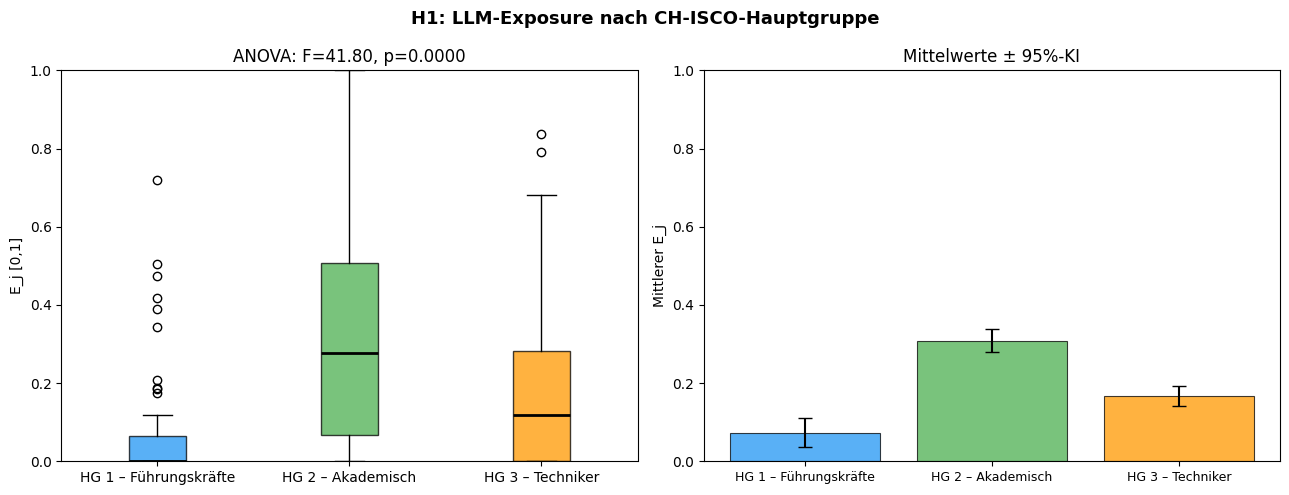

In [6]:
# ── Visualisierung H1 ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("H1: LLM-Exposure nach CH-ISCO-Hauptgruppe", fontsize=13, fontweight="bold")

# Boxplot
data_plot = [h1[h1["main_group"] == hg]["E_j"].dropna() for hg in [1,2,3]]
bp = ax1.boxplot(data_plot, labels=[hg_labels[h] for h in [1,2,3]], patch_artist=True,
                 medianprops={"color": "black", "linewidth": 2})
for patch, hg in zip(bp["boxes"], [1,2,3]):
    patch.set_facecolor(colors[hg]); patch.set_alpha(0.75)
ax1.set_ylabel("E_j [0,1]"); ax1.set_title(f"ANOVA: F={f_stat:.2f}, p={p_value:.4f}")
ax1.set_ylim(0, 1)

# Mittelwerte mit CI
means = [g.mean() for g in data_plot]
cis   = [stats.sem(g) * stats.t.ppf(0.975, len(g)-1) for g in data_plot]
ax2.bar([1,2,3], means, yerr=cis, color=[colors[h] for h in [1,2,3]],
        alpha=0.75, capsize=5, edgecolor="black", linewidth=0.8)
ax2.set_xticks([1,2,3]); ax2.set_xticklabels([hg_labels[h] for h in [1,2,3]], fontsize=9)
ax2.set_ylabel("Mittlerer E_j"); ax2.set_title("Mittelwerte ± 95%-KI"); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H1_anova.png", dpi=150, bbox_inches="tight")
plt.show()


---
## H2 – Random Forest: Fähigkeitsprädiktoren für E^sub_j

**Vorgehen:** Random Forest Regressor mit 5-facher Kreuzvalidierung.  
Feature Importance via permutation importance (Breiman, 2001).  
Ziel: Identifikation der Fähigkeitsdimensionen mit stärkstem Einfluss auf Substitutionsdruck.


In [7]:
# ── Datenvorbereitung H2 ──────────────────────────────────────────────────
feature_cols = [c for c in h2.columns if c not in ["soc_code", "E_sub_j"]]
X_h2 = h2[feature_cols].fillna(0).values
y_h2 = h2["E_sub_j"].values

print(f"Features: {len(feature_cols)}")
print(f"Sample:   {len(y_h2)} Berufe")
print(f"E^sub_j:  Mean={y_h2.mean():.3f} | Std={y_h2.std():.3f}")


Features: 161
Sample:   571 Berufe
E^sub_j:  Mean=0.208 | Std=0.221


In [16]:
# ── Random Forest Training + CV ───────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf, X_h2, y_h2, cv=5, scoring="r2")
print(f"5-fache CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"CV-Scores: {cv_scores.round(3)}")

# Volles Modell für Feature Importance
rf.fit(X_h2, y_h2)
print(f"\nIn-Sample R²: {rf.score(X_h2, y_h2):.3f}")


5-fache CV R²: 0.489 ± 0.142
CV-Scores: [0.646 0.408 0.31  0.668 0.412]

In-Sample R²: 0.956


In [17]:
# ── Feature Importance (Permutation) ──────────────────────────────────────
perm_imp = permutation_importance(rf, X_h2, y_h2, n_repeats=30, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": perm_imp.importances_mean,
    "std":        perm_imp.importances_std
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("=== Top 20 Feature Importance (Permutation) ===")
print(importance_df.head(20).to_string(index=False))

importance_df.to_csv(FIGURES / "H2_feature_importance.csv", index=False)
print("\nGespeichert → data/output/Hypothesen/H2_feature_importance.csv ✓")


=== Top 20 Feature Importance (Permutation) ===
                                                             feature  importance      std
                     Work Activities – Analyzing Data or Information    0.034367 0.002462
                                                Skills – Programming    0.031733 0.001506
                            Work Activities – Working with Computers    0.026641 0.001906
                            Work Activities – Processing Information    0.026404 0.001619
                                                Skills – Mathematics    0.018261 0.001347
                                  Abilities – Mathematical Reasoning    0.018080 0.001315
                   Work Activities – Assisting and Caring for Others    0.011783 0.000865
                                               Skills – Coordination    0.011451 0.000783
                                        Skills – Service Orientation    0.011258 0.000989
                               Knowledge – Computers

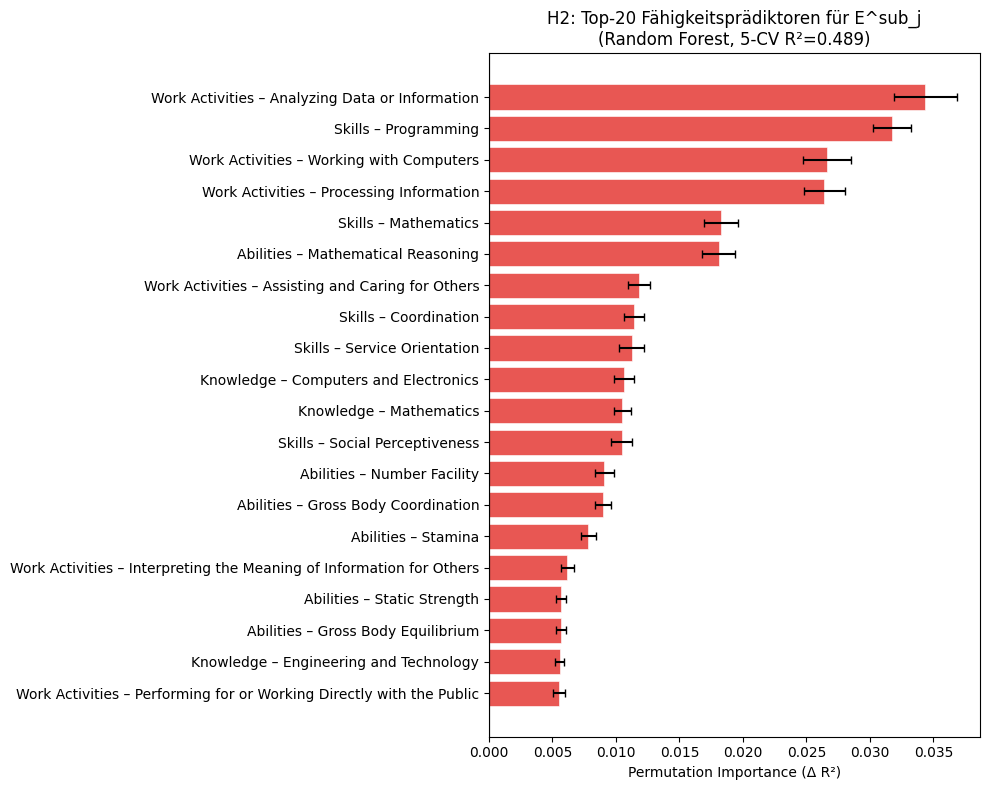

In [18]:
# ── Visualisierung Top 20 ─────────────────────────────────────────────────
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ["#E53935" if imp > 0 else "#90A4AE" for imp in top20["importance"]]
bars = ax.barh(top20["feature"], top20["importance"],
               xerr=top20["std"], color=colors_fi, alpha=0.85,
               capsize=3, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Permutation Importance (Δ R²)")
ax.set_title(f"H2: Top-20 Fähigkeitsprädiktoren für E^sub_j\n(Random Forest, 5-CV R²={cv_scores.mean():.3f})", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / "6_2_H2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## H3 – OLS-Regression: E_j und ΔBFS_j

**Vorgehen:** OLS-Regression mit ΔBFS_j als abhängiger Variable und E_j sowie  
Kontrollvariablen (Hauptgruppe, Qualifikationsniveau) als Prädiktoren.  
Robustheitsprüfung: Regression ohne Ausreisser (IQR-geflaggt).  
Quelle: Kläui & Siegenthaler (2025) als Orientierung für Effektgrössen.


In [19]:
# ── H3 Datenvorbereitung – ISCO-4-digit-Ebene ────────────────────────────
import statsmodels.formula.api as smf
from scipy import stats as sp_stats

# is_outlier sicher als Boolean konvertieren
final_isco_bfs["is_outlier"] = final_isco_bfs["is_outlier"].astype(str).isin(["True", "1", "1.0"])

# Hauptanalyse: ohne Ausreisser
h3_main = final_isco_bfs[~final_isco_bfs["is_outlier"]].copy()
h3_main["main_group"] = h3_main["main_group"].astype(int)

print(f"H3 Hauptanalyse:    {len(h3_main)} Berufsgruppen (ohne Ausreisser)")
print(f"H3 Robustheit:      {len(final_isco_bfs)} Berufsgruppen (inkl. Ausreisser)")
print(f"E_j_mean: {h3_main['E_j_mean'].describe()[['mean','std','min','max']].round(3).to_string()}")
print(f"delta_bfs: {h3_main['delta_bfs'].describe()[['mean','std','min','max']].round(3).to_string()}")

H3 Hauptanalyse:    148 Berufsgruppen (ohne Ausreisser)
H3 Robustheit:      156 Berufsgruppen (inkl. Ausreisser)
E_j_mean: mean    0.244
std     0.226
min     0.000
max     0.876
delta_bfs: mean     3.999
std     12.537
min    -25.657
max     37.403


In [20]:
# ── Modell 1: Bivariat E_j → ΔBFS_j ──────────────────────────────────────
model1 = smf.ols("delta_bfs ~ E_j_mean", data=h3_main).fit(cov_type="HC3")
print("=== Modell 1: Bivariat (ohne Ausreisser, ISCO-Ebene) ===")
print(model1.summary2().tables[1].round(3))
print(f"R²={model1.rsquared:.3f} | Adj. R²={model1.rsquared_adj:.3f} | N={int(model1.nobs)}")


=== Modell 1: Bivariat (ohne Ausreisser, ISCO-Ebene) ===
           Coef.  Std.Err.      z  P>|z|  [0.025  0.975]
Intercept  1.686     1.454  1.159  0.246  -1.164   4.535
E_j_mean   9.482     4.560  2.079  0.038   0.544  18.419
R²=0.029 | Adj. R²=0.023 | N=148


In [21]:
# ── Modell 2: Mit Hauptgruppen-Kontrolle ──────────────────────────────────
model2 = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=h3_main
).fit(cov_type="HC3")
print("=== Modell 2: Mit Hauptgruppen-Kontrolle ===")
print(model2.summary2().tables[1].round(3))
print(f"R²={model2.rsquared:.3f} | Adj. R²={model2.rsquared_adj:.3f} | N={int(model2.nobs)}")


=== Modell 2: Mit Hauptgruppen-Kontrolle ===
                                  Coef.  Std.Err.      z  P>|z|  [0.025  \
Intercept                         3.277     1.998  1.640  0.101  -0.639   
C(main_group, Treatment(2))[T.1] -3.734     2.924 -1.277  0.202  -9.465   
C(main_group, Treatment(2))[T.3] -1.376     2.316 -0.594  0.552  -5.915   
E_j_mean                          7.124     4.787  1.488  0.137  -2.259   

                                  0.975]  
Intercept                          7.193  
C(main_group, Treatment(2))[T.1]   1.996  
C(main_group, Treatment(2))[T.3]   3.163  
E_j_mean                          16.508  
R²=0.037 | Adj. R²=0.017 | N=148


In [22]:
# ── Modell-Vergleich ───────────────────────────────────────────────────────
model_robust = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=final_isco_bfs
).fit(cov_type="HC3")

comparison = pd.DataFrame({
    "Modell":       ["M1: Bivariat", "M2: + Hauptgruppe", "M_robust: inkl. Ausreisser"],
    "N":            [int(model1.nobs), int(model2.nobs), int(model_robust.nobs)],
    "R²":           [model1.rsquared, model2.rsquared, model_robust.rsquared],
    "Adj. R²":      [model1.rsquared_adj, model2.rsquared_adj, model_robust.rsquared_adj],
    "β E_j":        [model1.params["E_j_mean"], model2.params["E_j_mean"], model_robust.params["E_j_mean"]],
    "p E_j":        [model1.pvalues["E_j_mean"], model2.pvalues["E_j_mean"], model_robust.pvalues["E_j_mean"]],
}).round(4)
print(comparison.to_string(index=False))

# Speichern
comparison.to_csv(FIGURES / "H3_regression_results.csv", index=False)
print("\nGespeichert → data/processed/analysis_prep/H3_regression_results.csv ✓")


                    Modell   N     R²  Adj. R²  β E_j  p E_j
              M1: Bivariat 148 0.0292   0.0225 9.4819 0.0376
         M2: + Hauptgruppe 148 0.0373   0.0173 7.1244 0.1367
M_robust: inkl. Ausreisser 156 0.0092  -0.0104 6.3416 0.2836

Gespeichert → data/processed/analysis_prep/H3_regression_results.csv ✓


In [24]:
# ── Robustheitsprüfung: inkl. Ausreisser ──────────────────────────────────
# final_isco_bfs enthält alle Berufsgruppen inkl. Ausreisser
h3_robust = final_isco_bfs.copy()
h3_robust["main_group"] = h3_robust["main_group"].astype(int)

model_robust = smf.ols(
    "delta_bfs ~ E_j_mean + C(main_group, Treatment(2))",
    data=h3_robust
).fit(cov_type="HC3")

print("=== Robustheitsprüfung: Alle Berufe inkl. Ausreisser ===")
print(f"E_j: β={model_robust.params['E_j_mean']:.3f}, p={model_robust.pvalues['E_j_mean']:.4f}")
print(f"R²={model_robust.rsquared:.3f} (vs. {model2.rsquared:.3f} ohne Ausreisser)")

=== Robustheitsprüfung: Alle Berufe inkl. Ausreisser ===
E_j: β=6.342, p=0.2836
R²=0.009 (vs. 0.037 ohne Ausreisser)


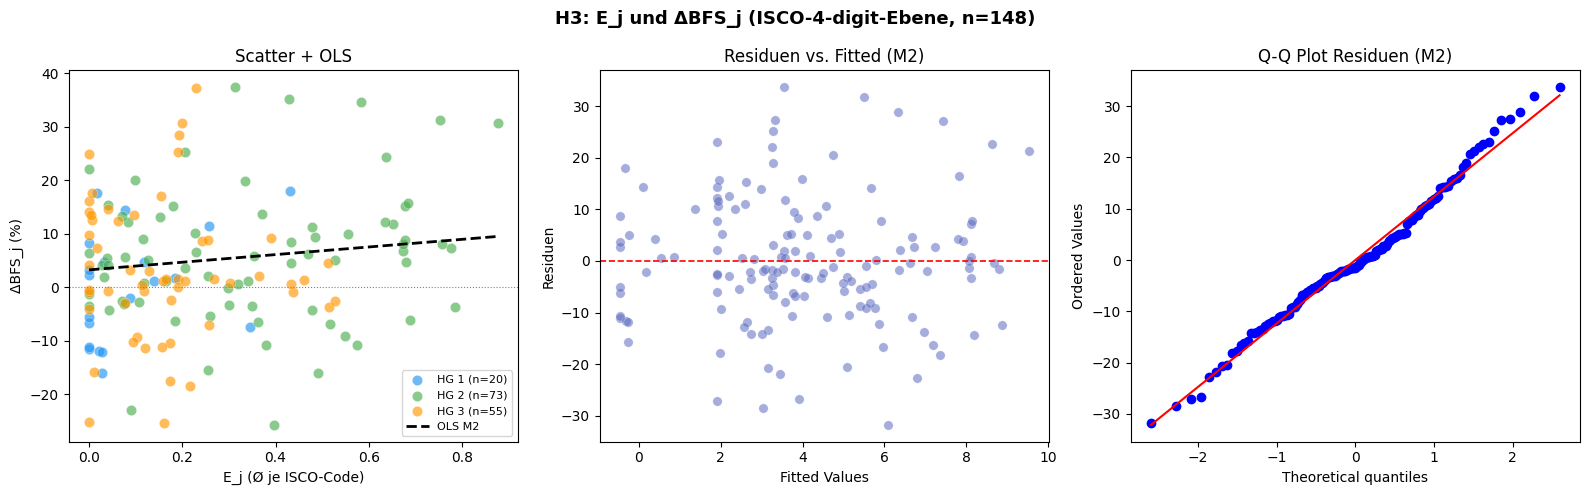

Abbildung gespeichert → output/EDA/6_2_H3_regression.png ✓


In [25]:
# ── Visualisierung H3 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"H3: E_j und ΔBFS_j (ISCO-4-digit-Ebene, n={len(h3_main)})",
    fontsize=13, fontweight="bold"
)

colors_h3 = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

# Scatter + Regressionslinie
ax = axes[0]
for hg in sorted(h3_main["main_group"].unique()):
    s = h3_main[h3_main["main_group"] == hg]
    ax.scatter(s["E_j_mean"], s["delta_bfs"],
               color=colors_h3.get(hg, "gray"), alpha=0.65, s=55,
               label=f"HG {hg} (n={len(s)})", edgecolors="white", linewidth=0.3)

x_pred = np.linspace(h3_main["E_j_mean"].min(), h3_main["E_j_mean"].max(), 100)
y_pred = model2.params["Intercept"] + model2.params["E_j_mean"] * x_pred
ax.plot(x_pred, y_pred, "k--", linewidth=2, label="OLS M2")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("E_j (Ø je ISCO-Code)")
ax.set_ylabel("ΔBFS_j (%)")
ax.set_title("Scatter + OLS")
ax.legend(fontsize=8)

# Residuen vs. Fitted
ax = axes[1]
ax.scatter(model2.fittedvalues, model2.resid,
           alpha=0.55, s=45, color="#5C6BC0", edgecolors="white", linewidth=0.3)
ax.axhline(0, color="red", linewidth=1.2, linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuen")
ax.set_title("Residuen vs. Fitted (M2)")

# Q-Q Plot
ax = axes[2]
sp_stats.probplot(model2.resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot Residuen (M2)")

plt.tight_layout()
plt.savefig(FIGURES / "6_2_H3_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Abbildung gespeichert → output/EDA/6_2_H3_regression.png ✓")
